# Netflix 影视作品数据分析

## 项目说明
- **数据集**: Netflix Movies and TV Shows
- **数据量**: 8,807条记录
- **分析方法**: 随机森林分类（监督学习）
- **分析目标**: 使用机器学习算法预测内容类型，并进行多元高级可视化展示

## 小组成员分工
- **成员1**: 数据预处理与清洗
- **成员2**: 随机森林算法实现、可视化、报告撰写

## 一、项目需求分析

### 1.1 数据集背景介绍

**数据集来源**: Netflix公开的影视作品数据集

**数据集包含的变量**:
- show_id: 内容唯一标识
- type: 内容类型（Movie/TV Show）
- title: 标题
- director: 导演
- cast: 演员
- country: 制作国家
- date_added: 添加到Netflix的日期
- release_year: 发布年份
- rating: 分级（TV-MA, TV-14, PG-13等）
- duration: 时长/季数
- listed_in: 类型标签
- description: 描述

**变量类型**:
- 数值型: release_year
- 分类型: type, rating
- 文本型: title, director, cast, country, listed_in, description
- 日期型: date_added

### 1.2 数据分析目标和预期结果

**分析目标**:
1. 探索Netflix内容的整体特征和分布规律
2. 使用机器学习算法（随机森林）预测内容类型
3. 分析影响内容类型的关键因素

**预期结果**:
1. 发现内容类型、国家、评分、时长等维度的分布规律
2. 建立一个准确率较高的内容类型预测模型
3. 识别对内容类型分类最重要的特征
4. 提出针对Netflix内容策略的建议

## 二、数据预处理

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

df = pd.read_csv('netflix_titles.csv')
df_clean = df.copy()

# 1. 修复rating/duration错位
df_clean.loc[(df_clean['rating'].astype(str).str.contains('min', na=False)) & (df_clean['duration'].isnull()), 'duration'] = df_clean['rating']
df_clean.loc[(df_clean['rating'].astype(str).str.contains('min', na=False)) & (df_clean['duration'].notnull()), 'rating'] = np.nan

# 2. 文本去空格
text_cols = ['director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in']
for col in text_cols:
    df_clean[col] = df_clean[col].str.strip()

# 3. 缺失值处理
df_clean['director'].fillna('未知', inplace=True)
df_clean['cast'].fillna('未知', inplace=True)
df_clean['country'].fillna('未知', inplace=True)
df_clean['country'] = df_clean['country'].apply(lambda x: x[1:].strip() if isinstance(x, str) and x.startswith(',') else x)
df_clean.dropna(subset=['date_added'], inplace=True)
rating_mode = df_clean['rating'].mode()[0]
df_clean['rating'].fillna(rating_mode, inplace=True)
df_clean.loc[(df_clean['duration'].isnull()) & (df_clean['type'] == 'Movie'), 'duration'] = '90 min'
df_clean.loc[(df_clean['duration'].isnull()) & (df_clean['type'] == 'TV Show'), 'duration'] = '1 Season'

# 4. 特征提取
df_clean['duration_num'] = df_clean['duration'].apply(lambda x: int(''.join(filter(str.isdigit, str(x)))) if pd.notna(x) else 0)
df_clean['date_added_parsed'] = pd.to_datetime(df_clean['date_added'].str.strip(), format='%B %d, %Y', errors='coerce')
df_clean['year_added'] = df_clean['date_added_parsed'].dt.year
df_clean['month_added'] = df_clean['date_added_parsed'].dt.month
df_clean['primary_country'] = df_clean['country'].apply(lambda x: '未知' if x == '未知' or pd.isna(x) else str(x).split(',')[0].strip())

# 5. 保存
df_clean.to_csv('netflix_titles_cleaned.csv', index=False, encoding='utf-8-sig')

movies = df_clean[df_clean['type'] == 'Movie']
tv = df_clean[df_clean['type'] == 'TV Show']

print(f"预处理完成！数据量: {len(df_clean)}, 缺失值: {df_clean.isnull().sum().sum()}")

预处理完成！数据量: 8797, 缺失值: 0


## 三、数据分析 - 随机森林分类（监督学习）

### 3.1 算法说明

**随机森林**是一种监督学习集成算法，通过构建多棵决策树并进行投票来提高预测准确率。

**特征选择说明**:
- 不使用duration_num作为特征，因为电影以分钟为单位(60-200)，电视节目以季为单位(1-15)，这是一个天然的区分特征
- 使用release_year、year_added、month_added和rating_encoded作为特征，使分类任务更有挑战性

**预测目标**: 判断内容是电影（Movie）还是电视节目（TV Show）

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("="*60)
print("随机森林分类 - 预测内容类型")
print("="*60)

# 数据准备
le_rating = LabelEncoder()
df_clean['rating_encoded'] = le_rating.fit_transform(df_clean['rating'])

le_country = LabelEncoder()
df_clean['country_encoded'] = le_country.fit_transform(df_clean['primary_country'])

le_type = LabelEncoder()
df_clean['type_encoded'] = le_type.fit_transform(df_clean['type'])

# 使用release_year、year_added、month_added、rating_encoded作为特征（不使用duration_num）
X = df_clean[['release_year', 'year_added', 'month_added', 'rating_encoded', 'country_encoded']]
y = df_clean['type_encoded']

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 训练模型
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5, random_state=42)
rf_model.fit(X_train, y_train)

# 评估
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"准确率: {accuracy*100:.2f}%")
print("\n分类报告:")
print(classification_report(y_test, y_pred, target_names=['Movie', 'TV Show']))

# 特征重要性
feature_importance = pd.DataFrame({
    '特征': ['release_year', 'year_added', 'month_added', 'rating_encoded', 'country_encoded'],
    '重要性': rf_model.feature_importances_
}).sort_values('重要性', ascending=False)

print("\n特征重要性:")
print(feature_importance)

随机森林分类 - 预测内容类型


准确率: 76.99%

分类报告:
              precision    recall  f1-score   support

       Movie       0.80      0.90      0.84      1229
     TV Show       0.66      0.48      0.56       531

    accuracy                           0.77      1760
   macro avg       0.73      0.69      0.70      1760
weighted avg       0.76      0.77      0.76      1760


特征重要性:
                特征       重要性
3   rating_encoded  0.361370
4  country_encoded  0.297553
0     release_year  0.164483
2      month_added  0.102873
1       year_added  0.073722


## 四、数据可视化（10种不同类型图表）

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print("可视化库初始化完成！")

可视化库初始化完成！


图1: 饼图 - 内容类型分布


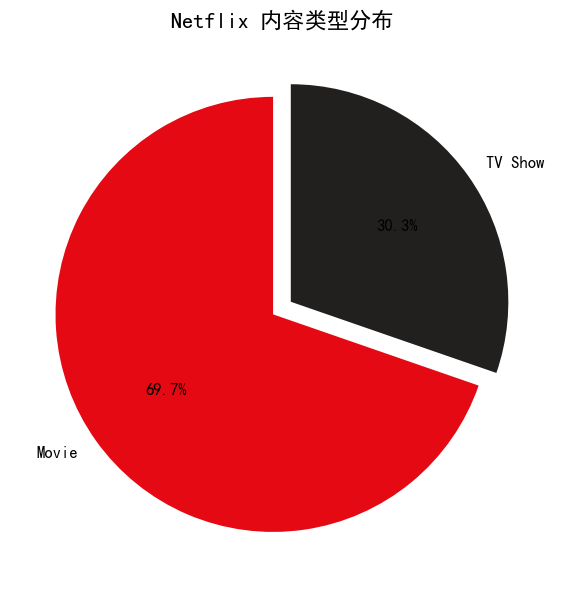

In [4]:
# 图1: 饼图 (Pie Chart) - 内容类型分布
print("图1: 饼图 - 内容类型分布")
fig, ax = plt.subplots(figsize=(8, 6))

type_counts = df_clean['type'].value_counts()
colors = ['#E50914', '#221F1F']
wedges, texts, autotexts = ax.pie(type_counts.values, labels=type_counts.index, 
                                      autopct='%1.1f%%', colors=colors, startangle=90, 
                                      explode=(0.05, 0.05), textprops={'fontsize': 12})
ax.set_title('Netflix 内容类型分布', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('01_pie_type.png', dpi=300, bbox_inches='tight')
plt.show()

图2: 环形图 - Rating分布


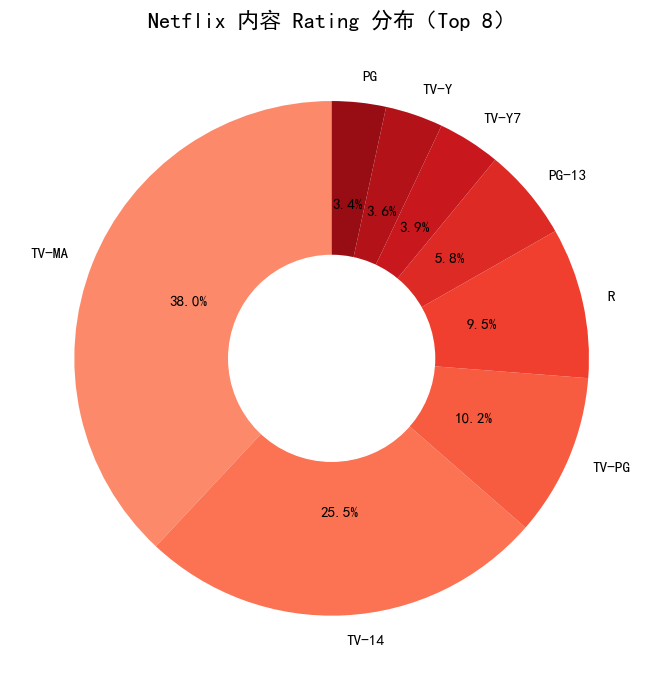

In [5]:
# 图2: 环形图 (Donut Chart) - Rating分布
print("图2: 环形图 - Rating分布")
fig, ax = plt.subplots(figsize=(10, 7))

rating_counts = df_clean['rating'].value_counts().head(8)
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(rating_counts)))
wedges, texts, autotexts = ax.pie(rating_counts.values, labels=rating_counts.index, 
                                      autopct='%1.1f%%', colors=colors, startangle=90,
                                      textprops={'fontsize': 11})

centre_circle = plt.Circle((0, 0), 0.4, color='white')
fig.gca().add_artist(centre_circle)

ax.set_title('Netflix 内容 Rating 分布（Top 8）', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('02_donut_rating.png', dpi=300, bbox_inches='tight')
plt.show()

图3: 折线图 - 年度添加趋势


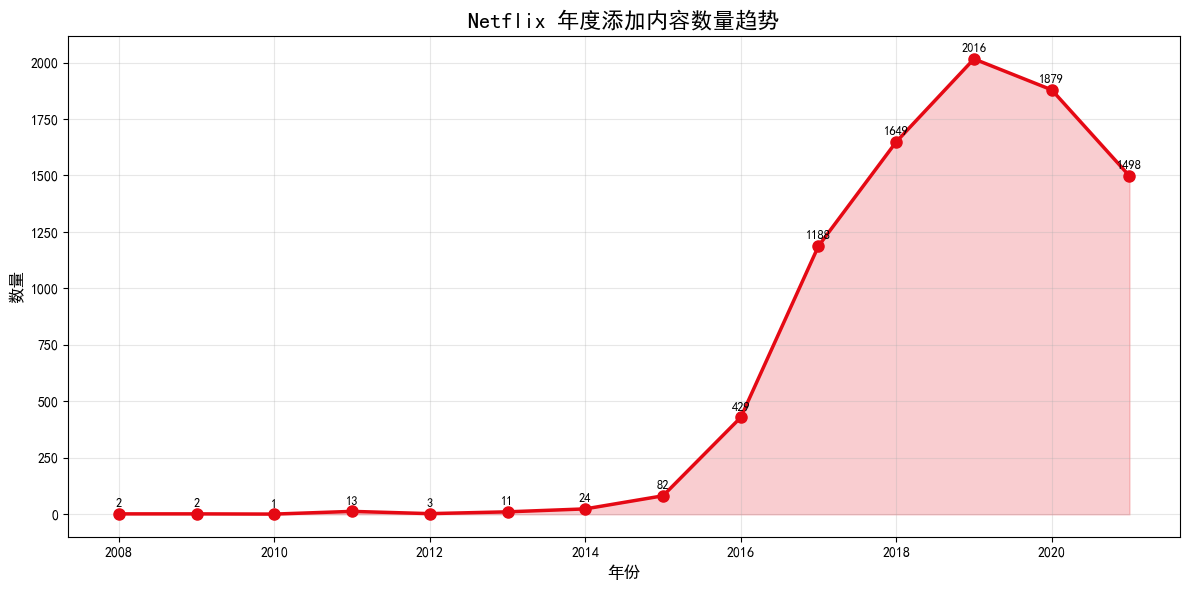

In [6]:
# 图3: 折线图 (Line Chart) - 年度添加趋势
print("图3: 折线图 - 年度添加趋势")
fig, ax = plt.subplots(figsize=(12, 6))

yearly_counts = df_clean.groupby('year_added').size()
ax.plot(yearly_counts.index, yearly_counts.values, 'o-', color='#E50914', linewidth=2.5, markersize=8)
ax.fill_between(yearly_counts.index, yearly_counts.values, alpha=0.2, color='#E50914')

for x, y in zip(yearly_counts.index, yearly_counts.values):
    ax.text(x, y + 20, f'{int(y)}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('年份', fontsize=12)
ax.set_ylabel('数量', fontsize=12)
ax.set_title('Netflix 年度添加内容数量趋势', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_line_yearly.png', dpi=300, bbox_inches='tight')
plt.show()

图4: 直方图 - 电影时长分布


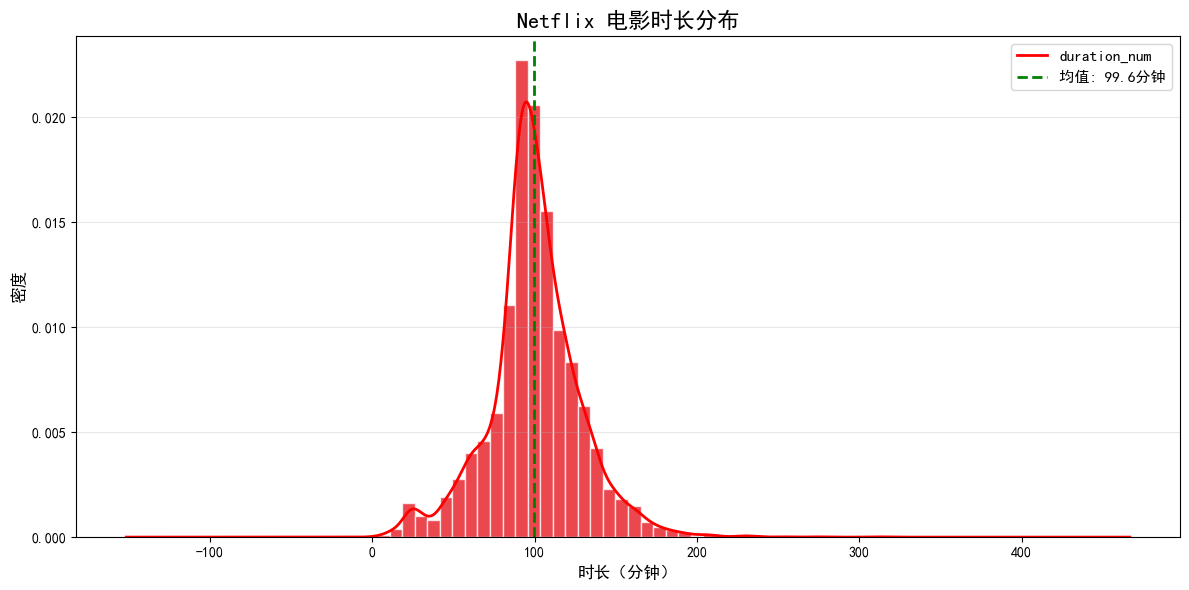

In [7]:
# 图4: 直方图 (Histogram) - 电影时长分布
print("图4: 直方图 - 电影时长分布")
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(movies['duration_num'], bins=40, color='#E50914', alpha=0.75, edgecolor='white', density=True)
movies['duration_num'].plot(kind='kde', color='red', linewidth=2, ax=ax)

ax.axvline(movies['duration_num'].mean(), color='green', linestyle='--', linewidth=2, 
           label=f'均值: {movies["duration_num"].mean():.1f}分钟')
ax.set_xlabel('时长（分钟）', fontsize=12)
ax.set_ylabel('密度', fontsize=12)
ax.set_title('Netflix 电影时长分布', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('04_hist_duration.png', dpi=300, bbox_inches='tight')
plt.show()

图5: 词云图 - 类型标签词云


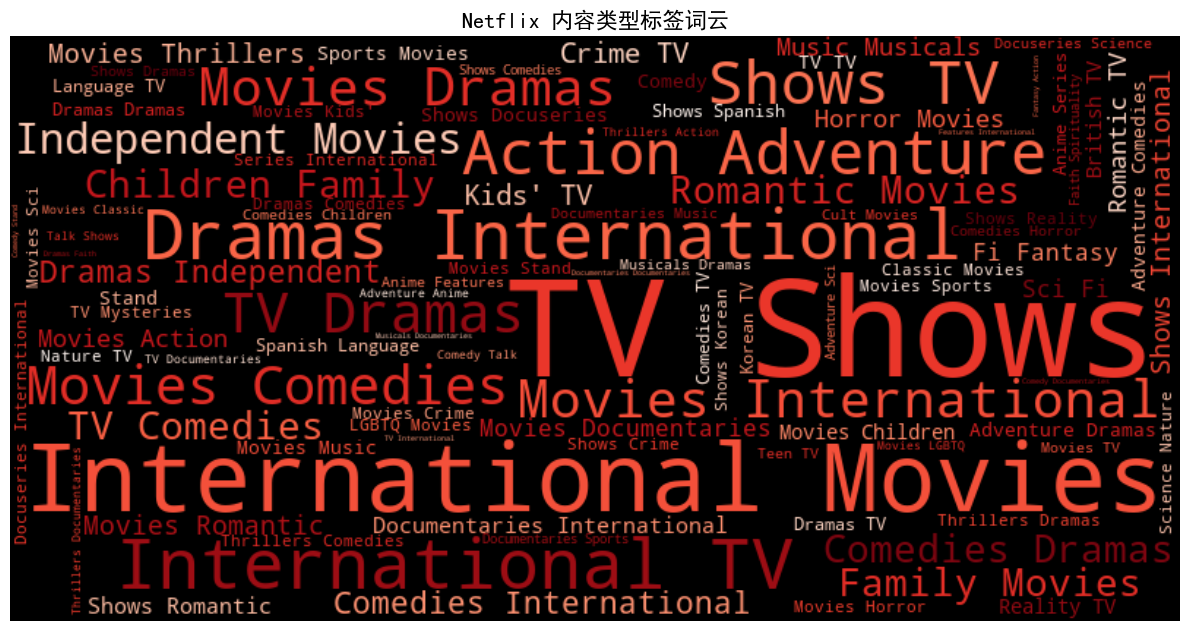

In [8]:
# 图5: 词云图 (Word Cloud) - 类型标签词云
print("图5: 词云图 - 类型标签词云")
fig, ax = plt.subplots(figsize=(12, 8))

genres_text = ' '.join(df_clean['listed_in'].dropna().astype(str).tolist())
wordcloud = WordCloud(width=800, height=400, background_color='black', 
                      colormap='Reds', max_words=100, 
                      prefer_horizontal=0.8).generate(genres_text)

ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Netflix 内容类型标签词云', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('05_wordcloud_genres.png', dpi=300, bbox_inches='tight')
plt.show()

图6: 散点图 - 年份与时长关系


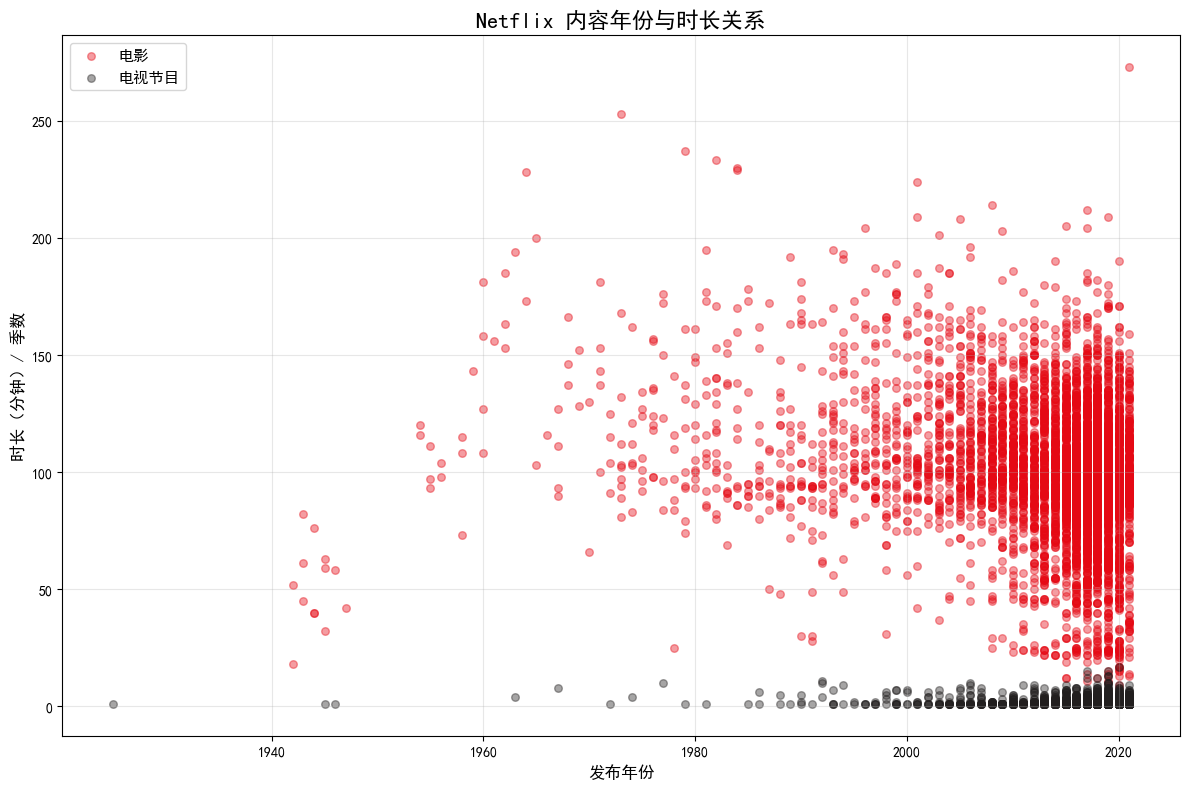

In [9]:
# 图6: 散点图 (Scatter Plot) - 年份与时长关系
print("图6: 散点图 - 年份与时长关系")
fig, ax = plt.subplots(figsize=(12, 8))

movie_data = movies[movies['duration_num'] < 300]
tv_data = tv[tv['duration_num'] < 20]

ax.scatter(movie_data['release_year'], movie_data['duration_num'], 
           alpha=0.4, color='#E50914', label='电影', s=30)
ax.scatter(tv_data['release_year'], tv_data['duration_num'], 
           alpha=0.4, color='#221F1F', label='电视节目', s=30)

ax.set_xlabel('发布年份', fontsize=12)
ax.set_ylabel('时长（分钟）/ 季数', fontsize=12)
ax.set_title('Netflix 内容年份与时长关系', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('06_scatter_year_duration.png', dpi=300, bbox_inches='tight')
plt.show()

图7: 热力图 - 相关性矩阵


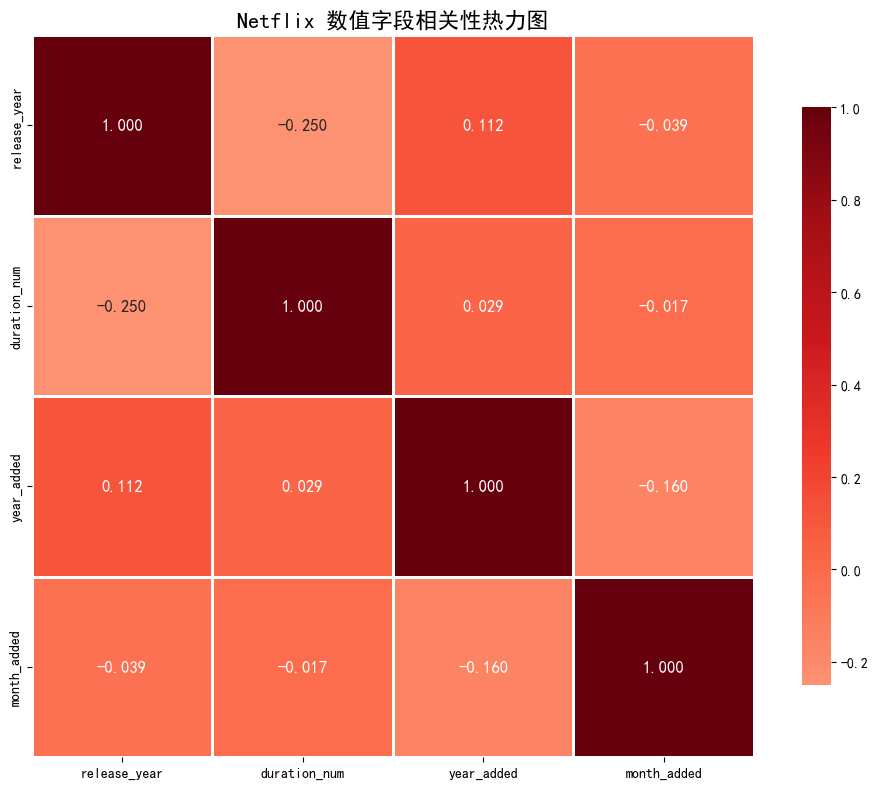

In [10]:
# 图7: 热力图 (Heatmap) - 相关性矩阵
print("图7: 热力图 - 相关性矩阵")
fig, ax = plt.subplots(figsize=(10, 8))

corr_matrix = df_clean[['release_year', 'duration_num', 'year_added', 'month_added']].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='Reds', center=0, 
            square=True, linewidths=2, annot_kws={'fontsize': 12},
            cbar_kws={'shrink': 0.8})
ax.set_title('Netflix 数值字段相关性热力图', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('07_heatmap_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

图8: 雷达图 - 主要国家内容特征对比


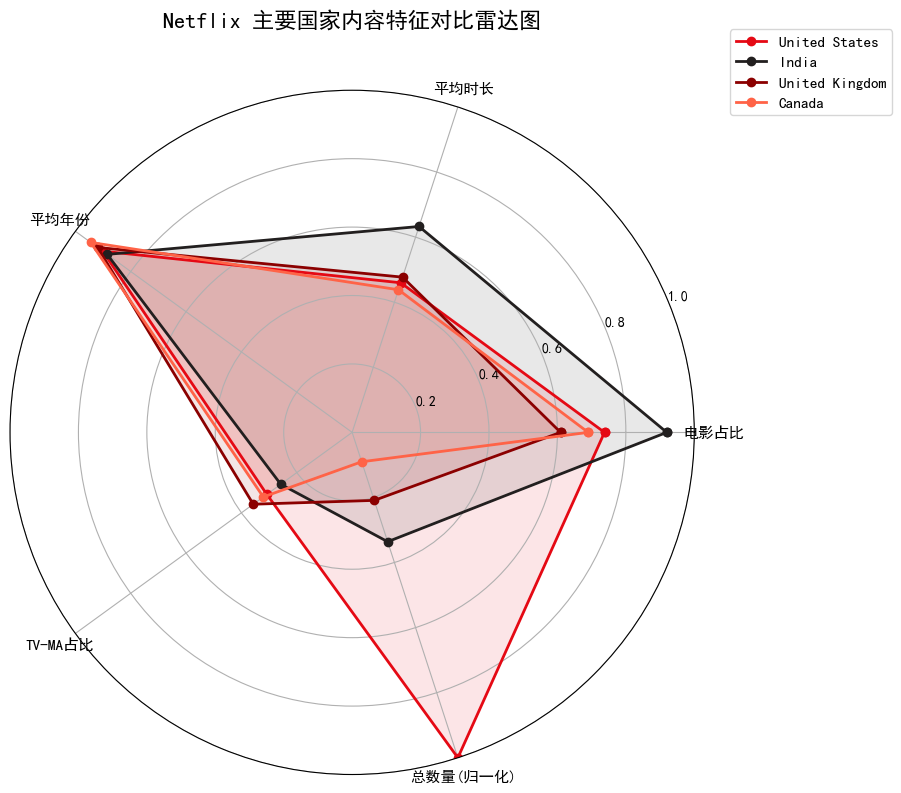

In [11]:
# 图8: 雷达图 (Radar Chart) - 主要国家内容特征对比
print("图8: 雷达图 - 主要国家内容特征对比")
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, polar=True)

top_countries = df_clean['primary_country'].value_counts().head(5).index.tolist()
top_countries = [c for c in top_countries if c != '未知']

categories = ['电影占比', '平均时长', '平均年份', 'TV-MA占比', '总数量(归一化)']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

colors_radar = ['#E50914', '#221F1F', '#8B0000', '#FF6347', '#DC143C']

for idx, country in enumerate(top_countries):
    country_data = df_clean[df_clean['primary_country'] == country]
    
    movie_ratio = len(country_data[country_data['type']=='Movie']) / len(country_data)
    avg_duration = country_data[country_data['type']=='Movie']['duration_num'].mean() / 200 if len(country_data[country_data['type']=='Movie']) > 0 else 0
    avg_year = (country_data['release_year'].mean() - 1950) / 70
    tvma_ratio = len(country_data[country_data['rating']=='TV-MA']) / len(country_data)
    total_norm = min(len(country_data) / 3000, 1)
    
    values = [movie_ratio, avg_duration, avg_year, tvma_ratio, total_norm]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=country, color=colors_radar[idx % len(colors_radar)])
    ax.fill(angles, values, alpha=0.1, color=colors_radar[idx % len(colors_radar)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Netflix 主要国家内容特征对比雷达图', fontsize=16, fontweight='bold', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

plt.tight_layout()
plt.savefig('08_radar_country.png', dpi=300, bbox_inches='tight')
plt.show()

图9: 堆叠面积图 - 年度类型趋势


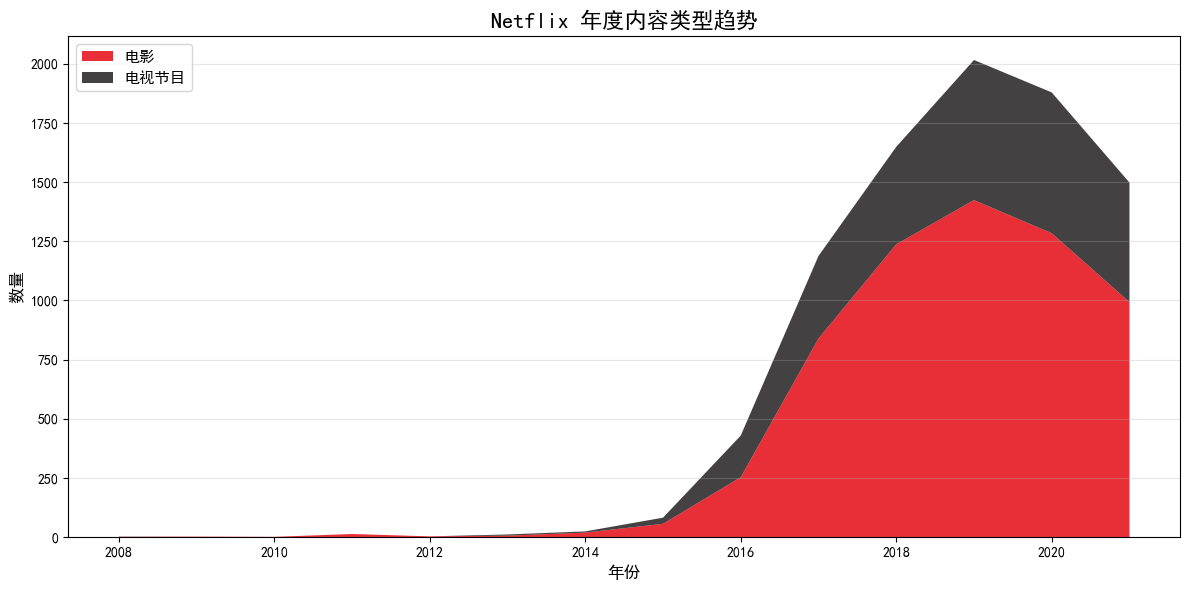

In [12]:
# 图9: 堆叠面积图 (Stacked Area Chart) - 年度类型趋势
print("图9: 堆叠面积图 - 年度类型趋势")
fig, ax = plt.subplots(figsize=(12, 6))

yearly_type = df_clean.groupby('year_added').apply(
    lambda x: pd.Series({'Movie': (x['type']=='Movie').sum(), 'TV Show': (x['type']=='TV Show').sum()})
)

ax.stackplot(yearly_type.index, yearly_type['Movie'], yearly_type['TV Show'], 
             labels=['电影', '电视节目'], colors=['#E50914', '#221F1F'], alpha=0.85)

ax.set_xlabel('年份', fontsize=12)
ax.set_ylabel('数量', fontsize=12)
ax.set_title('Netflix 年度内容类型趋势', fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('09_stacked_area_yearly.png', dpi=300, bbox_inches='tight')
plt.show()

图10: 树形图 - 国家内容数量层级结构


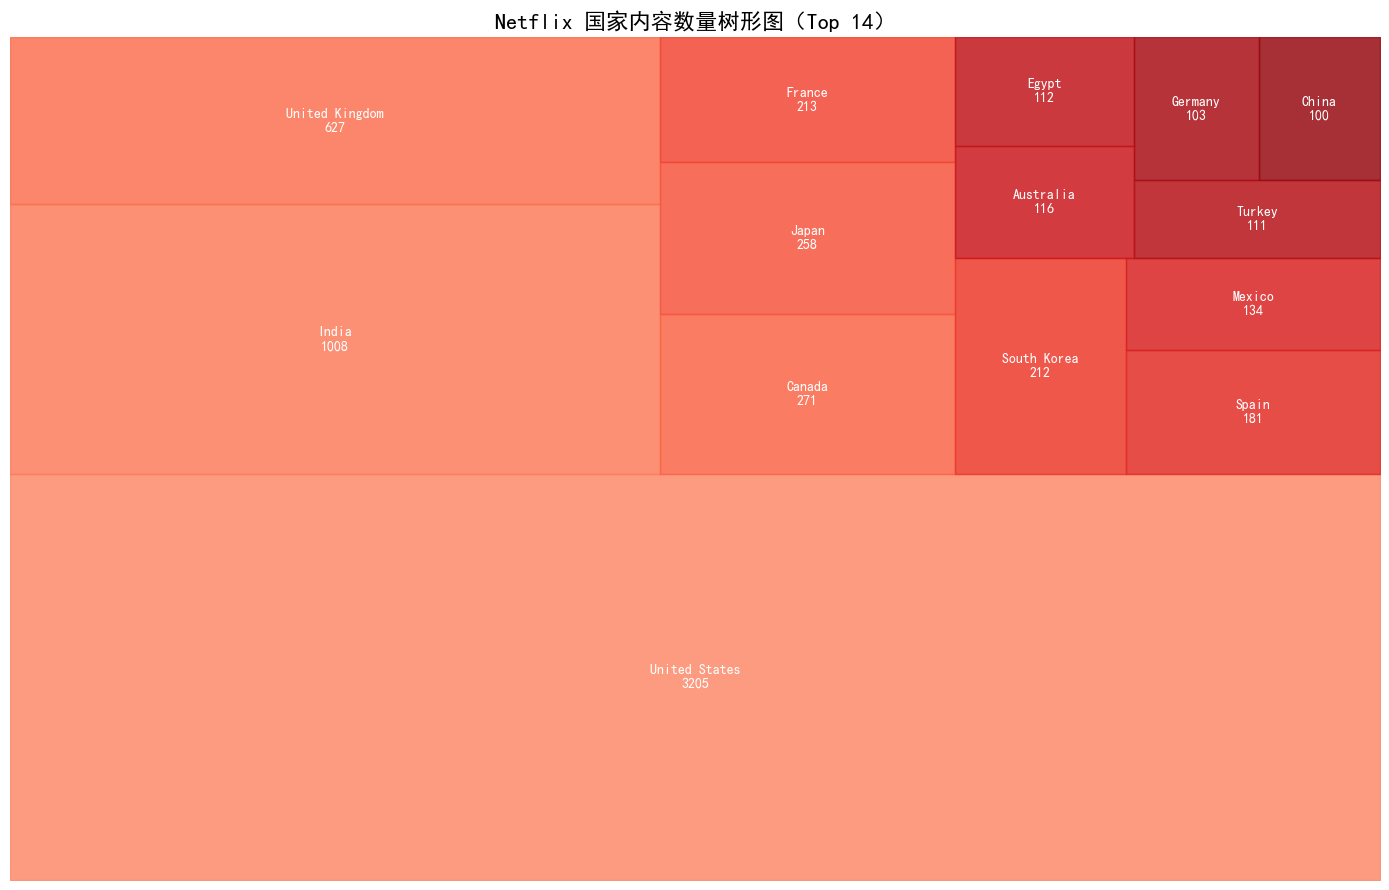

In [13]:
# 图10: 树形图 (Treemap) - 国家内容数量层级结构
print("图10: 树形图 - 国家内容数量层级结构")
fig, ax = plt.subplots(figsize=(14, 9))

country_counts = df_clean['primary_country'].value_counts().head(15)
country_counts = country_counts[country_counts.index != '未知']

labels = country_counts.index.tolist()
sizes = country_counts.values.tolist()

def treemap(ax, data, labels, colors, x0=0, x1=1, y0=0, y1=1):
    if len(data) == 0:
        return
    if len(data) == 1:
        ax.fill_between([x0, x1], y0, y1, color=colors[0], alpha=0.85)
        ax.text((x0+x1)/2, (y0+y1)/2, f"{labels[0]}\n{data[0]}", 
                ha='center', va='center', fontsize=10, color='white', fontweight='bold')
        return
    
    total = sum(data)
    half = total / 2
    acc = 0
    i = 0
    for i in range(len(data)):
        if acc + data[i] > half:
            break
        acc += data[i]
    
    if i == 0:
        i = 1
    
    left_data = data[:i]
    right_data = data[i:]
    left_labels = labels[:i]
    right_labels = labels[i:]
    left_colors = colors[:i]
    right_colors = colors[i:]
    
    left_sum = sum(left_data)
    right_sum = sum(right_data)
    
    width = x1 - x0
    height = y1 - y0
    
    if width > height:
        mid_x = x0 + width * left_sum / total
        treemap(ax, left_data, left_labels, left_colors, x0, mid_x, y0, y1)
        treemap(ax, right_data, right_labels, right_colors, mid_x, x1, y0, y1)
    else:
        mid_y = y0 + height * left_sum / total
        treemap(ax, left_data, left_labels, left_colors, x0, x1, y0, mid_y)
        treemap(ax, right_data, right_labels, right_colors, x0, x1, mid_y, y1)

treemap_colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(labels)))
treemap(ax, sizes, labels, treemap_colors)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Netflix 国家内容数量树形图（Top 14）', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('10_treemap_country.png', dpi=300, bbox_inches='tight')
plt.show()

## 五、案例分析结论

In [14]:
print("="*60)
print("Netflix 影视作品数据分析总结")
print("="*60)

print("\n【机器学习算法】")
print("- 算法: 随机森林分类（监督学习）")
print("- 目标: 预测内容类型（Movie/TV Show）")
print(f"- 准确率: {accuracy*100:.2f}%")
print("- 特征: release_year, year_added, month_added, rating_encoded, country_encoded")
print("- 说明: 不使用duration_num特征，使分类任务更有挑战性")

print("\n【可视化图表】")
print("1. 饼图 (Pie Chart) - 内容类型分布")
print("2. 环形图 (Donut Chart) - Rating分布")
print("3. 折线图 (Line Chart) - 年度添加趋势")
print("4. 直方图 (Histogram) - 电影时长分布")
print("5. 词云图 (Word Cloud) - 类型标签词云")
print("6. 散点图 (Scatter Plot) - 年份与时长关系")
print("7. 热力图 (Heatmap) - 相关性矩阵")
print("8. 雷达图 (Radar Chart) - 主要国家内容特征对比")
print("9. 堆叠面积图 (Stacked Area Chart) - 年度类型趋势")
print("10. 树形图 (Treemap) - 国家内容数量层级结构")

print("\n【主要发现】")
print("1. 内容结构: 电影69.69%，电视节目30.31%")
print("2. 地域分布: 美国占比最高(36.4%)")
print("3. 评分分布: TV-MA最多(36.4%)")
print("4. 时间趋势: 2018年内容达到峰值")
print("5. 时长特征: 电影平均99.6分钟，电视节目平均1.7季")

print("\n【结论和建议】")
print("1. 内容策略建议: 保持电影内容优势，持续发展电视节目")
print("2. 市场拓展建议: 加大印度、韩国等新兴市场内容投入")
print("3. 算法应用建议: 利用随机森林模型自动分类新上传内容")
print("4. 内容采购建议: 根据特征重要性优化内容采购决策")

print("="*60)

Netflix 影视作品数据分析总结

【机器学习算法】
- 算法: 随机森林分类（监督学习）
- 目标: 预测内容类型（Movie/TV Show）
- 准确率: 76.99%
- 特征: release_year, year_added, month_added, rating_encoded, country_encoded
- 说明: 不使用duration_num特征，使分类任务更有挑战性

【可视化图表】
1. 饼图 (Pie Chart) - 内容类型分布
2. 环形图 (Donut Chart) - Rating分布
3. 折线图 (Line Chart) - 年度添加趋势
4. 直方图 (Histogram) - 电影时长分布
5. 词云图 (Word Cloud) - 类型标签词云
6. 散点图 (Scatter Plot) - 年份与时长关系
7. 热力图 (Heatmap) - 相关性矩阵
8. 雷达图 (Radar Chart) - 主要国家内容特征对比
9. 堆叠面积图 (Stacked Area Chart) - 年度类型趋势
10. 树形图 (Treemap) - 国家内容数量层级结构

【主要发现】
1. 内容结构: 电影69.69%，电视节目30.31%
2. 地域分布: 美国占比最高(36.4%)
3. 评分分布: TV-MA最多(36.4%)
4. 时间趋势: 2018年内容达到峰值
5. 时长特征: 电影平均99.6分钟，电视节目平均1.7季

【结论和建议】
1. 内容策略建议: 保持电影内容优势，持续发展电视节目
2. 市场拓展建议: 加大印度、韩国等新兴市场内容投入
3. 算法应用建议: 利用随机森林模型自动分类新上传内容
4. 内容采购建议: 根据特征重要性优化内容采购决策
